# FFS — Fast FITS Statistics: przewodnik

`pyaraucaria.ffs.FFS` liczy szybkie statystyki klatki CCD do oceny jakości obserwacji
(tło, szum, wykrywanie gwiazd, FWHM, eliptyczność, gradient tła, linie/satelity).
Docelowo ma być etapem redukcji fotometrycznej, tworzącym maski złych pikseli,
kolumn i śladów satelitów dla photutils.

Ten notatnik pracuje **wyłącznie na prawdziwej klatce z OCA** i pokazuje:

1. wczytanie i wyświetlenie klatki FITS,
2. statystyki klatki,
3. wykrywanie gwiazd i pomiar ich kształtu,
4. gradient tła,
5. wykrywanie linii (satelity),
6. wywołania używane w produkcji (TOI, `Focus`).

Testy na klatkach syntetycznych ze znaną prawdą (generator, porównanie wyników z prawdą,
uruchomienie testów) są w osobnym notatniku **`ffs_tests.ipynb`**.

**Konwencje** (sprawdzane w testach): `image[y, x]` — pierwszy indeks to wiersz (y),
drugi kolumna (x), od 0. Kąt `theta` to orientacja dłuższej osi gwiazdy, mierzona
przeciwnie do wskazówek zegara od osi +x, w radianach, w przedziale [−π/2, π/2).
Obrazy rysujemy z `origin="lower"`, więc oś y rośnie w górę i kąty na rysunkach
zgadzają się z `theta`.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval

# Use the repository version of pyaraucaria.
REPO = os.path.abspath("..")
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from pyaraucaria.ffs import FFS

warnings.simplefilter("ignore", RuntimeWarning)
%matplotlib inline
# JPEG keeps the notebook small: full-frame noise does not compress as PNG
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}
plt.rcParams["figure.dpi"] = 100


def show(img, ax=None, title=None, extent=None):
    # zscale display, y axis up
    ax = ax or plt.gca()
    norm = ImageNormalize(img, interval=ZScaleInterval())
    ax.imshow(img, origin="lower", cmap="gray", norm=norm, interpolation="nearest",
              extent=extent)
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")
    if title:
        ax.set_title(title)
    return ax


def stats_table(stats, descriptions, keys=None):
    keys = keys or list(stats)
    rows = []
    for k in keys:
        v = stats[k]
        v = f"{float(v):.4g}" if np.ndim(v) == 0 else str(np.round(v, 4))
        rows.append((k, v, descriptions.get(k, "")))
    return Table(rows=rows, names=["key", "value", "description"])

## 1. Klatka FITS

Przykładowa klatka z OCA. Aby użyć innej, zmień `FITS_PATH` (i `SATURATION`).

In [2]:
FITS_PATH = os.path.expanduser("~/work/data/fits_examples/jk15c_0154_73367.fits")
# jk15c: bright stars in this frame have flat tops at 23.6k-27k ADU, so the
# camera saturates far below 50000. 23000 is an estimate from those plateaus --
# confirm with the camera specification.
SATURATION = 23000

with fits.open(FITS_PATH) as hdul:
    data = hdul[0].data
    hdr = hdul[0].header
source = os.path.basename(FITS_PATH)

print(f"{source}: shape={data.shape}, dtype={data.dtype}")
for key in ["OBJECT", "FILTER", "EXPTIME", "DATE-OBS", "GAIN"]:
    print(f"  {key:9s} {hdr.get(key)}")

jk15c_0154_73367.fits: shape=(4096, 4108), dtype=uint16
  OBJECT    SA110
  FILTER    B
  EXPTIME   100.0
  DATE-OBS  2023-07-29T05:36:29.398684
  GAIN      Gain 1


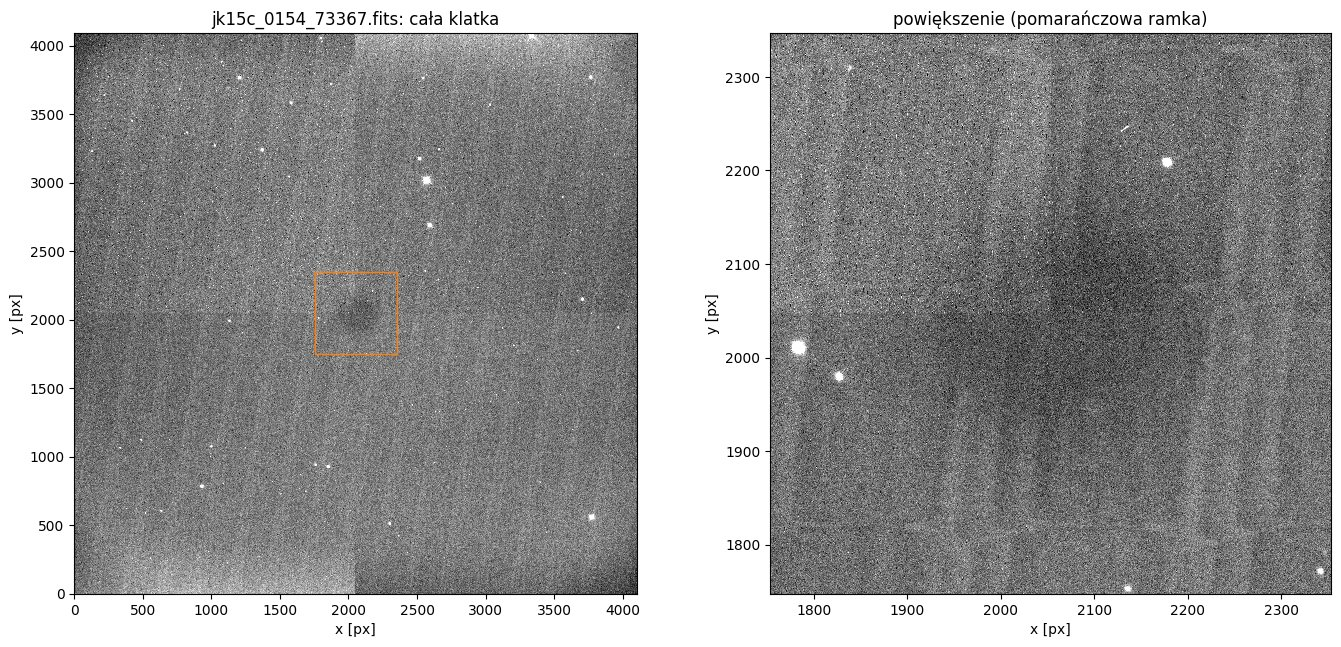

In [3]:
ny, nx = data.shape
zy, zx, zs = ny // 2, nx // 2, 300          # zoom: centre of the frame, 300 px half-size
zoom = (slice(zy - zs, zy + zs), slice(zx - zs, zx + zs))
zoom_extent = (zx - zs - 0.5, zx + zs - 0.5, zy - zs - 0.5, zy + zs - 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
show(data, axes[0], f"{source}: cała klatka")
axes[0].add_patch(plt.Rectangle((zx - zs, zy - zs), 2 * zs, 2 * zs, fill=False, color="tab:orange"))
show(data[zoom], axes[1], "powiększenie (pomarańczowa ramka)", extent=zoom_extent)
plt.tight_layout()

Na klatce jk15c widać podział na kwadranty (granica ok. x = 2054, y = 2048) i pionowe
struktury w powiększeniu. Oba efekty są bardzo słabe: kwadranty mają tę samą medianę
(1217 ADU), skok na granicy w x to ok. 2 ADU (0,2σ), a rozrzut median kolumn ok. 0,4 ADU.
Na rysunku wyolbrzymia je wąskie rozciągnięcie zscale (σ tła ≈ 9,5 ADU).

## 2. Statystyki klatki — `mk_stats()`

Odporne estymatory: mediana jako tło i `q_sigma` — połowa rozstępu kwantyli 15,9–84,1%
(dla rozkładu normalnego równa σ, mało czuła na gwiazdy). `noise` to oczekiwany szum
z Poissona i szumu odczytu dla podanych `gain` i `rn_noise`.
`mk_stats()` trzeba wywołać przed `find_stars()`.

In [4]:
ffs = FFS(data, gain=1.0, rn_noise=0.0)
ffs.saturation = SATURATION
ffs.mk_stats()
stats_table(ffs.stats["frame"], ffs.stats_description["frame"])

key,value,description
str13,str9,str48
min,1139,Minimal pixel value in the image
max,2.699e+04,Maximum pixel value in the image
mean,1218,Mean pixel value (arithmetic average)
median,1217,Median pixel value (robust background estimator)
rms,112.2,Standard deviation of pixel values
q_sigma_lower,9,Lower 1-sigma estimate from 50% - 15.9% quantile
q_sigma_upper,10,Upper 1-sigma estimate from 84.1% - 50% quantile
q_sigma,9.5,Robust sigma estimated from 15.9–84.1% quantiles
noise,34.89,Expected total noise (Poisson + read noise)


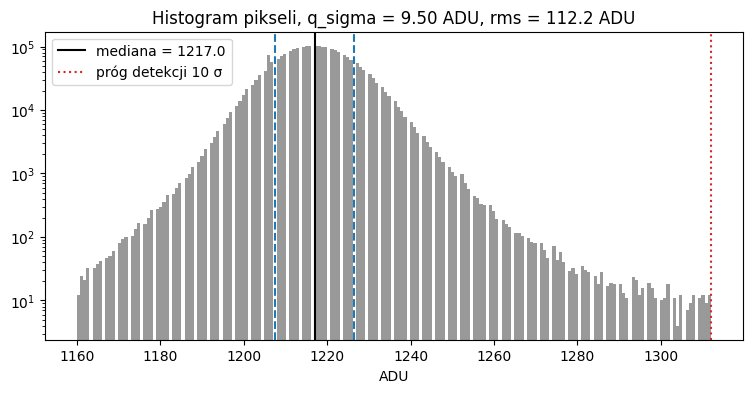

In [5]:
lo, hi = ffs.median - 6 * ffs.q_sigma, ffs.median + 10 * ffs.q_sigma
sample = data.ravel()[::7]
plt.figure(figsize=(9, 4))
plt.hist(sample, bins=200, range=(lo, hi), color="0.6")
plt.axvline(ffs.median, color="k", label=f"mediana = {ffs.median:.1f}")
for s, ls in [(1, "--"), (-1, "--")]:
    plt.axvline(ffs.median + s * ffs.q_sigma, color="tab:blue", ls=ls)
plt.axvline(ffs.median + 10 * ffs.q_sigma, color="tab:red", ls=":", label="próg detekcji 10 σ")
plt.yscale("log")
plt.xlabel("ADU")
plt.title(f"Histogram pikseli, q_sigma = {ffs.q_sigma:.2f} ADU, rms = {ffs.rms:.1f} ADU")
plt.legend();

## 3. Gwiazdy

### 3a. Wykrywanie — `find_stars()`

Piksel jest kandydatem, gdy przekracza `median + threshold · σ` **oraz** jest lokalnym
maksimum obrazu wygładzonego gaussem o zadanym `fwhm`. Wynik: `ffs.coo` (tablica
`[y, x]`), `ffs.adu` (wartość piku), `ffs.stars` (tabela `x, y, max_adu`),
posortowane malejąco wg piku.

In [6]:
ffs.find_stars(threshold=10, fwhm=5)
print(f"wykryto {len(ffs.coo)} gwiazd")
ffs.stars[:5]

wykryto 193 gwiazd


x,y,max_adu
int64,int64,uint16
3337,4069,26960
3778,560,26219
2595,2688,23600
2574,3014,22666
933,786,20532


threshold =   5 σ  ->     727 źródeł


threshold =  10 σ  ->     193 źródeł


threshold =  20 σ  ->     108 źródeł


threshold =  50 σ  ->      54 źródeł


threshold = 100 σ  ->      32 źródeł


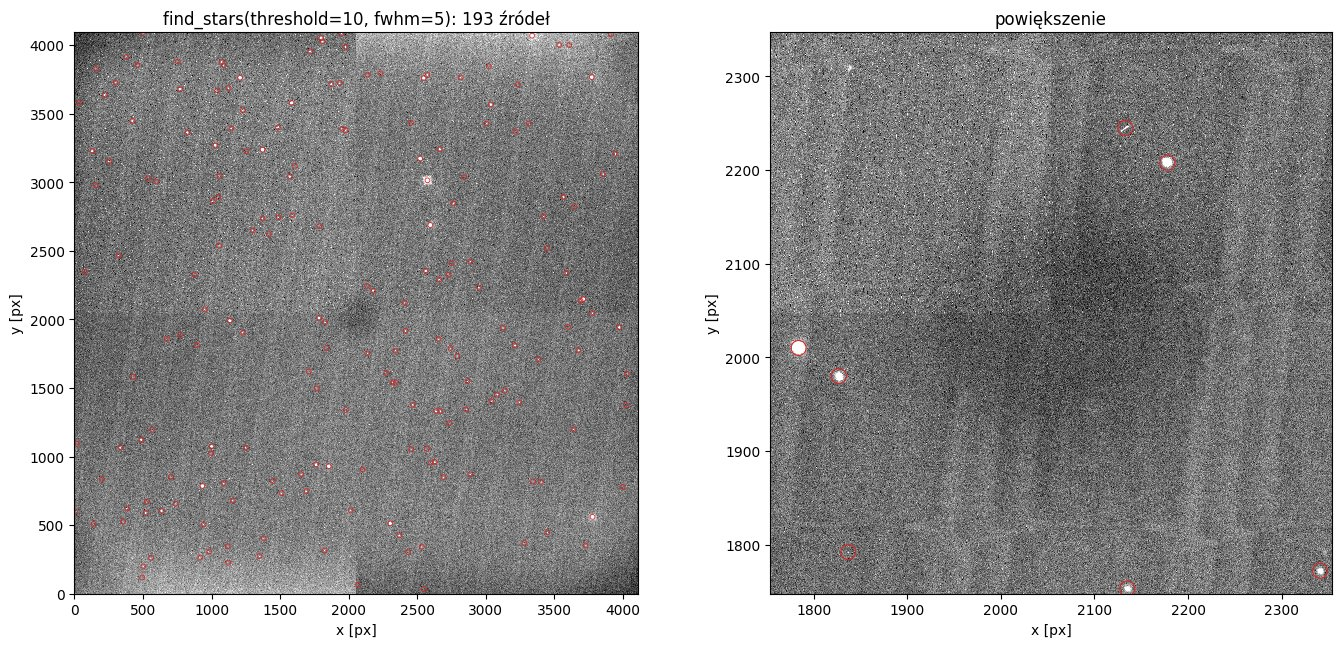

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
show(data, axes[0], f"find_stars(threshold=10, fwhm=5): {len(ffs.coo)} źródeł")
axes[0].scatter(ffs.stars["x"], ffs.stars["y"], s=12, facecolors="none", edgecolors="tab:red", lw=0.6)

show(data[zoom], axes[1], "powiększenie", extent=zoom_extent)
inside = ((abs(ffs.stars["x"] - zx) < zs) & (abs(ffs.stars["y"] - zy) < zs))
for x, y in zip(ffs.stars["x"][inside], ffs.stars["y"][inside]):
    axes[1].add_patch(Circle((x, y), 8, fill=False, color="tab:red", lw=0.8))
plt.tight_layout()

for th in (5, 10, 20, 50, 100):
    f = FFS(data); f.mk_stats(); f.find_stars(threshold=th, fwhm=5)
    print(f"threshold = {th:3d} σ  ->  {len(f.coo):6d} źródeł")

Dodatkowe filtry `find_stars()` odrzucają artefakty jednopikselowe (gorące piksele,
promienie kosmiczne): `max_concentration` (jaka część strumienia siedzi w pikselu
centralnym), `min_pixels_above_threshold` (ile pikseli ponad progiem ma źródło),
`min_smoothed_sigma` (próg na obrazie wygładzonym). `rank_by` zmienia tylko kolejność.
Ich działanie na wstrzykniętych gorących pikselach pokazuje `ffs_tests.ipynb`.

### 3b. Pomiar gwiazd — `star_info()` i `calc_star_stats()`

Dla `N_stars` najjaśniejszych nienasyconych gwiazd, w pudełku ±`box` px:
tło z brzegu pudełka, FWHM z profili w x i y, eliptyczność `1 − b/a` i kąt `theta`
z **momentów adaptacyjnych** (okno gaussowskie dopasowywane do gwiazdy; odporne na
szum i sąsiadów), CPE, CI. Do tabeli trafiają tylko gwiazdy z udanym pomiarem.
`calc_star_stats()` liczy mediany dla klatki po odrzuceniu odstających (`clip` σ).

**Uwaga o nasyceniu:** `ffs.saturation` musi odpowiadać kamerze. Gwiazdy z pikiem
≥ `saturation` są pomijane. Przy zbyt wysokiej wartości (np. domyślne 50000 dla jk15c)
do pomiaru trafiają gwiazdy ze spłaszczonym wierzchołkiem: FWHM 7–11 px i fałszywie
duża eliptyczność. Statystyki klatki są na to częściowo odporne dzięki `clip`.

In [8]:
ffs.star_info(box=15, N_stars=50)
ffs.calc_star_stats(clip=4)
print(f"zmierzono {len(ffs.stars)} gwiazd, do statystyk klatki użyto {ffs.frame_used_stars}")
keys = ["fwhm", "fwhm_x", "fwhm_y", "ellipticity", "theta_spread", "cpe", "shape", "ci", "used_stars"]
stats_table(ffs.stats["frame"], ffs.stats_description["frame"], keys)

zmierzono 50 gwiazd, do statystyk klatki użyto 44


key,value,description
str12,str7,str169
fwhm,4.296,Median of the full width at half maximum (FWHM) of the brightest sources in the frame
fwhm_x,4.113,Median FWHM measured along the X axis
fwhm_y,4.546,Median FWHM measured along the Y axis
ellipticity,0.1457,"Median source ellipticity (1 − b/a), describing PSF elongation"
theta_spread,0.1962,"Axial (period pi) circular spread of source position angles, in radians. Low spread with high ellipticity indicates a common elongation direction (e.g. tracking or wind)"
cpe,0.03648,"Median central pixel excess (CPE) of detected sources; higher values indicate sharper, more centrally concentrated profiles"
shape,0.7187,Median PSF shape parameter defined as CPE × FWHM^2
ci,0.8172,Median concentration index (CI) of detected stars in the frame;
used_stars,44,How many star were used to evaluate thos statistics


In [9]:
ffs.stars["x", "y", "max_adu", "fwhm", "ellipticity", "theta", "ci"][:8]

x,y,max_adu,fwhm,ellipticity,theta,ci
int64,int64,uint16,float64,float64,float64,float64
933,786,20532,4.146100983309516,0.14585779549798195,-0.9670919624737007,0.80662160109707
1855,930,18255,4.27871936827583,0.12862104944361263,-0.9219060515334481,0.8126009165321113
2521,3173,18159,4.6154356352235215,0.14124485647208973,-1.2949077084750282,0.8296854710719954
1208,3762,17100,5.010703877209077,0.20534700176689236,-1.3409416349638255,0.8463772140002873
3710,2148,16152,4.309578771537949,0.09299990097256017,-0.925551367956571,0.8163900769888793
1372,3237,15894,4.761561778298962,0.19290149637904952,-1.2373783557673574,0.8375121192306825
3772,3767,12522,4.739940869171894,0.10475395288330036,-1.5149796454554414,0.8416754996638078
1584,3579,9300,4.8733353902945655,0.20228520213121493,-1.3193021742506126,0.8356952682325445


Wycinki najjaśniejszych zmierzonych gwiazd. Elipsa ma osie równe FWHM wzdłuż osi
głównej i pobocznej (z momentów adaptacyjnych) i jest obrócona o `theta`.

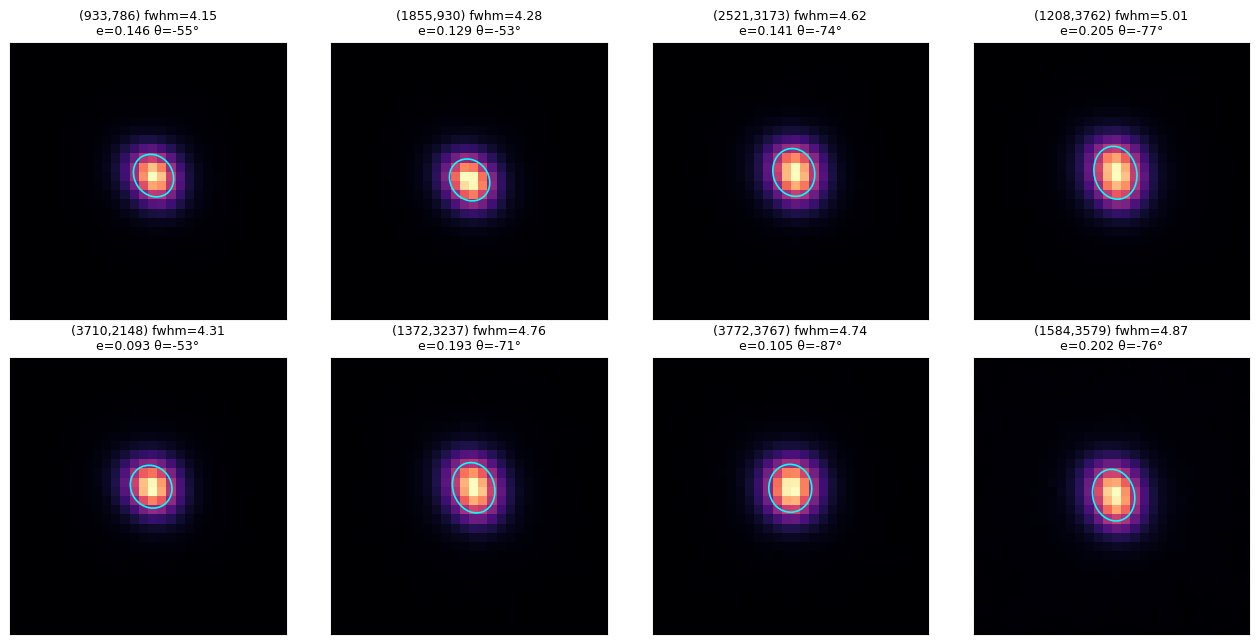

In [10]:
def star_cut(image, x, y, box=15):
    cut = image[max(0, y - box):y + box, max(0, x - box):x + box].astype(float)
    border = np.concatenate([cut[0], cut[-1], cut[:, 0], cut[:, -1]])
    return cut - np.median(border)


n_show = min(8, len(ffs.stars))
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, row in zip(axes.ravel(), ffs.stars[:n_show]):
    x, y = int(row["x"]), int(row["y"])
    cut = star_cut(data, x, y)
    f, e, t = FFS.adaptive_moments(cut)
    cx, cy = FFS.centroid(cut)
    fa = f * 2 / (2 - e)            # major-axis FWHM from mean FWHM and e
    ax.imshow(cut, origin="lower", cmap="magma", interpolation="nearest")
    ax.add_patch(Ellipse((cx, cy), fa, fa * (1 - e), angle=np.rad2deg(t),
                         fill=False, color="cyan", lw=1.2))
    ax.set_title(f"({x},{y}) fwhm={row['fwhm']:.2f}\ne={row['ellipticity']:.3f} "
                 f"θ={np.rad2deg(row['theta']):.0f}°", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

Rozkład kształtów w polu: kreska w miejscu gwiazdy ma długość proporcjonalną do
eliptyczności i kierunek `theta`. Wspólny kierunek przy niezerowej eliptyczności
(mały `theta_spread`) wskazuje na prowadzenie, wiatr albo optykę; losowe kierunki —
gwiazdy w praktyce okrągłe.

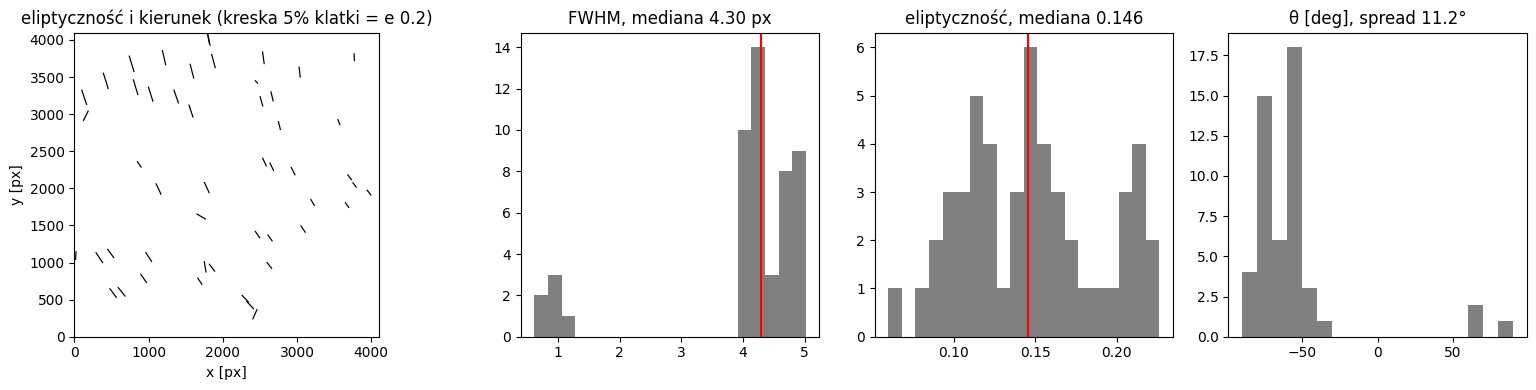

In [11]:
s = ffs.stars
fig, axes = plt.subplots(1, 4, figsize=(16, 4), gridspec_kw={"width_ratios": [1.6, 1, 1, 1]})
ax = axes[0]
ax.quiver(s["x"], s["y"], s["ellipticity"] * np.cos(s["theta"]), s["ellipticity"] * np.sin(s["theta"]),
          angles="xy", scale_units="xy", scale=0.2 / (0.05 * nx), headwidth=0, headlength=0,
          headaxislength=0, pivot="middle", width=0.004)
ax.set_xlim(0, nx); ax.set_ylim(0, ny); ax.set_aspect("equal")
ax.set_title("eliptyczność i kierunek (kreska 5% klatki = e 0.2)")
ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
axes[1].hist(s["fwhm"], bins=20, color="0.5"); axes[1].axvline(ffs.frame_fwhm, color="r")
axes[1].set_title(f"FWHM, mediana {ffs.frame_fwhm:.2f} px")
axes[2].hist(s["ellipticity"], bins=20, color="0.5"); axes[2].axvline(ffs.frame_ellipticity, color="r")
axes[2].set_title(f"eliptyczność, mediana {ffs.frame_ellipticity:.3f}")
axes[3].hist(np.rad2deg(s["theta"]), bins=18, range=(-90, 90), color="0.5")
axes[3].set_title(f"θ [deg], spread {np.rad2deg(ffs.frame_theta_spread):.1f}°")
plt.tight_layout()

## 4. Gradient tła — `sky_gradient(n_segments)`

Klatka jest dzielona na `n_segments × n_segments` prostokątów. Mediany segmentów
są dopasowywane powierzchnią kwadratową `a0 + a1·x + a2·y + a3·x² + a4·xy + a5·y²`.
`bkg_max_amplitude` to rozpiętość modelu w środkach segmentów, `bkg_frame_gradient`
— największa różnica między przeciwległymi brzegami. Obie wielkości liczone są
w środkach segmentów, więc zależą od `n_segments`.
Mapa po prawej pokazuje residua median segmentów względem modelu.

bkg_max_amplitude  = 10.30 ADU
bkg_frame_gradient = 7.99 ADU


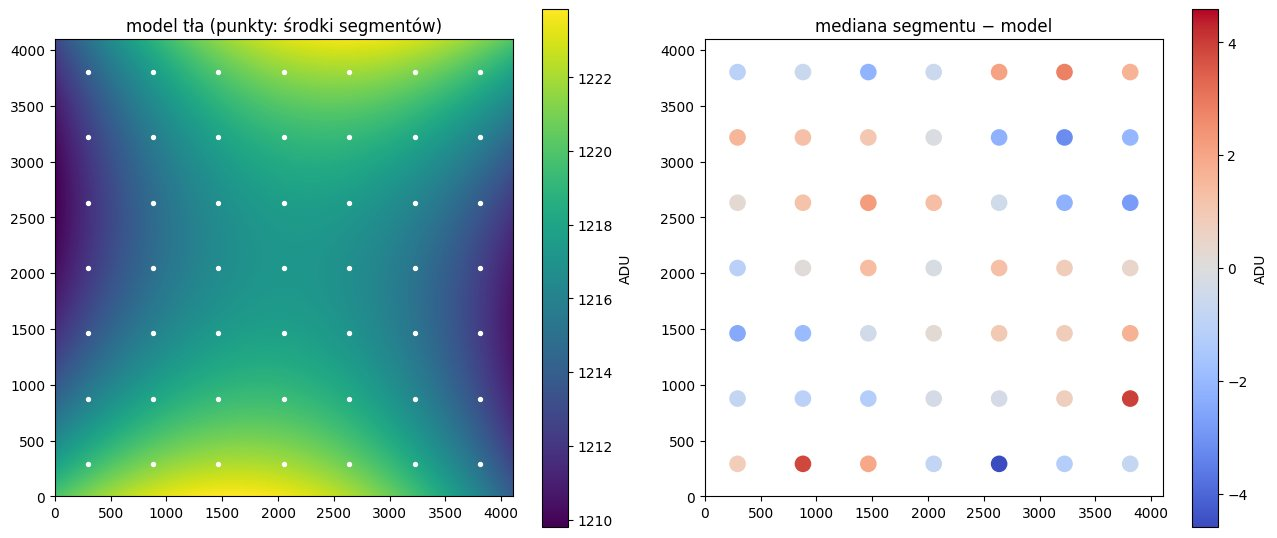

In [12]:
ffs.sky_gradient(n_segments=7)
print(f"bkg_max_amplitude  = {ffs.stats['frame']['bkg_max_amplitude']:.2f} ADU")
print(f"bkg_frame_gradient = {ffs.stats['frame']['bkg_frame_gradient']:.2f} ADU")

yy, xx = np.mgrid[0:ny:16, 0:nx:16]
model = FFS.polysurf(xx, yy, ffs.sky_surface_coeff)
seg_medians = [np.median(sg["subframe"]) for sg in FFS.make_segments(data, n_segments=7)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
im = axes[0].imshow(model, origin="lower", extent=(0, nx, 0, ny), cmap="viridis")
axes[0].scatter(ffs.sky_surface_x, ffs.sky_surface_y, c="w", s=8)
plt.colorbar(im, ax=axes[0], label="ADU")
axes[0].set_title("model tła (punkty: środki segmentów)")
resid = np.array(seg_medians) - np.array(ffs.sky_surface_bkg)
sc = axes[1].scatter(ffs.sky_surface_x, ffs.sky_surface_y, c=resid, cmap="coolwarm", s=120,
                     vmin=-np.abs(resid).max(), vmax=np.abs(resid).max())
plt.colorbar(sc, ax=axes[1], label="ADU")
axes[1].set_xlim(0, nx); axes[1].set_ylim(0, ny); axes[1].set_aspect("equal")
axes[1].set_title("mediana segmentu − model")
plt.tight_layout()

## 5. Linie i satelity — `find_lines()`

Transformata Hougha na masce `ffs.maska` (piksele > mediana + 3σ, z `mk_stats()`).
Każda linia to `(rho, theta)`: `x·cos θ + y·sin θ = ρ`. Wynik w `ffs.stats["lines"]`
(`val` — liczba głosów, posortowane malejąco).

**Znane ograniczenia** (oznaczone w testach jako `expectedFailure`, do poprawy przy
maskach satelitów): bezwzględny próg głosów (`th_signal=100`) sprawia, że na dużej
klatce z wieloma gwiazdami „linii” są setki lub tysiące; jeden ślad bywa raportowany
jako kilka linii; ρ jest przesunięte o ułamek piksela; pamięć rośnie jak
`liczba pikseli maski × 180`.

In [13]:
ffs.find_lines()
print(f"{source}: {len(ffs.lines_val)} linii, piksele w masce: {ffs.maska.sum()}")
print("najsilniejsze (val, rho, theta[deg]):")
# Here the strongest "lines" are horizontal (theta = +-90 deg) at the top edge
# (rho ~ +-4092, frame height 4096) -- not satellites; see limitations above.
# A correctly detected (synthetic) satellite trail is shown in ffs_tests.ipynb.
for v, r, t in list(zip(ffs.lines_val, ffs.lines_rho, np.rad2deg(ffs.lines_theta)))[:5]:
    print(f"  {v:6.0f} {r:9.1f} {t:7.1f}")

jk15c_0154_73367.fits: 2001 linii, piksele w masce: 116458
najsilniejsze (val, rho, theta[deg]):
     506   -4091.9   -90.0
     506    4092.9    90.0
     478    4090.9    90.0
     478   -4089.9   -90.0
     460   -4093.9   -90.0


## 6. Wywołania produkcyjne

Tak FFS wołają TOI (`TOI/fits_gui.py`, `FFS_Worker`) i `pyaraucaria.focus.Focus.fwhm`.
Te ścieżki są zamrożone w testach regresyjnych (`ffs_tests.ipynb`), więc każda zmiana ich wyników
jest widoczna.

In [14]:
# TOI: FFS_Worker.run (TOI transposes the image first)
toi = FFS(np.transpose(data))
toi.saturation = 45000
toi.calc_frame_fwhm(threshold=10, fwhm=5, box=15, N_stars=50, clip=4)
toi.sky_gradient(n_segments=7)
keys = ["fwhm", "ellipticity", "shape", "cpe", "ci", "median", "q_sigma",
        "bkg_max_amplitude", "bkg_frame_gradient"]
print("TOI:", {k: round(float(toi.stats["frame"][k]), 3) for k in keys})

from pyaraucaria.focus import Focus
print("Focus.fwhm:", Focus.fwhm(data, saturation=SATURATION))

TOI: {'fwhm': 4.31, 'ellipticity': 0.146, 'shape': 0.719, 'cpe': 0.036, 'ci': 0.818, 'median': 1217.0, 'q_sigma': 9.5, 'bkg_max_amplitude': 10.3, 'bkg_frame_gradient': 7.991}


Focus.fwhm: 4.489572674399747


## 7. Co dalej

- **Maski**: maska bitowa (`uint16`, osobny bit na przyczynę: nasycenie, przelew, gorący
  piksel, zła kolumna, satelita, …) o kształcie obrazu, z zamianą na maskę logiczną dla
  photutils (`True` = pomiń). Detektory w kolejności: nasycenie i przelewy → gorące piksele
  → złe kolumny → satelity.
- **Hough**: próg względny, tłumienie sąsiednich maksimów, poprawna siatka ρ, mniejsze
  zużycie pamięci, zamiana linii na pas pikseli o zadanej szerokości.
- Testy masek oceniane względem `truth["mask_*"]` z `ffs_synth`.